# PROYECTO ULAB — Fase 5: Evaluacion Final y Presentacion
**Semanas 11-12 | Prediccion de Histogramas de Carga de Trabajo**  
UAX x Tecnicas Reunidas

---
### Estructura
1. Consolidacion de resultados de todas las fases  
2. Evaluacion exhaustiva del modelo ganador con los 3 esquemas de CV  
3. Analisis de residuos final  
4. Visualizaciones ejecutivas para Tecnicas Reunidas  
5. Analisis de error por departamento  
6. Recomendaciones operativas  
7. Tabla resumen lista para informe/presentacion
---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/ULAB'
DATA_PATH = f'{BASE_PATH}/data'
MODELOS_PATH = f'{BASE_PATH}/modelos'
RESULTADOS_PATH = f'{BASE_PATH}/resultados'
NOTEBOOKS_PATH = f'{BASE_PATH}/notebooks'

import os
for p in [DATA_PATH, MODELOS_PATH, RESULTADOS_PATH, NOTEBOOKS_PATH]:
    os.makedirs(p, exist_ok=True)

print("DATA:", DATA_PATH)
print("MODELOS:", MODELOS_PATH)
print("RESULTADOS:", RESULTADOS_PATH)

Mounted at /content/drive
DATA: /content/drive/MyDrive/Colab Notebooks/ULAB/data
MODELOS: /content/drive/MyDrive/Colab Notebooks/ULAB/modelos
RESULTADOS: /content/drive/MyDrive/Colab Notebooks/ULAB/resultados


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
import joblib

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import jarque_bera

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

print('Entorno listo')
print(f'TensorFlow: {tf.__version__}')

Entorno listo
TensorFlow: 2.20.0


## 1. Consolidacion de resultados de todas las fases

In [3]:
# =========================
# 1. Consolidación de resultados de todas las fases
# =========================

df_f2_reg = pd.read_csv(f'{RESULTADOS_PATH}/resultados_fase2_regresion.csv')
df_f2_ser = pd.read_csv(f'{RESULTADOS_PATH}/resultados_fase2_series.csv')
df_f3 = pd.read_csv(f'{RESULTADOS_PATH}/resultados_fase3_lstm.csv')
df_f4 = pd.read_csv(f'{RESULTADOS_PATH}/resultados_fase4_final.csv')

print('=== Resultados Fase 2 — Regresión supervisada (escenario real E2: C1 -> C3) ===')
f2_real = (
    df_f2_reg[df_f2_reg['CV'] == 'E2-C1->C3'][['Modelo', 'RMSE', 'R2', 'MAE', 'MAPE_pct']]
    .sort_values('RMSE')
    .reset_index(drop=True)
)
display(f2_real)

print('\n=== Resultados Fase 2 — Series temporales clásicas ===')
if not df_f2_ser.empty:
    resumen_series = (
        df_f2_ser.groupby('Modelo')[['RMSE', 'R2', 'MAE']]
        .mean()
        .round(3)
        .sort_values('RMSE')
        .reset_index()
    )
    display(resumen_series)
else:
    print('No hay resultados de series temporales disponibles.')

print('\n=== Resultados Fase 3 — Modelos secuenciales ===')
f3_resumen = (
    df_f3[['Modelo', 'RMSE', 'R2', 'MAE', 'MAPE_pct']]
    .dropna(subset=['RMSE'])
    .sort_values('RMSE')
    .reset_index(drop=True)
)
display(f3_resumen)

print('\n=== Ranking final Fase 4 ===')
display(df_f4.sort_values('RMSE').reset_index(drop=True))

=== Resultados Fase 2 — Regresión supervisada (escenario real E2: C1 -> C3) ===


,Modelo,RMSE,R2,MAE,MAPE_pct
0,Lasso,13.85,0.9287,7.57,23.64
1,LinearRegression,13.95,0.9277,7.80,24.41
2,Ridge,13.95,0.9277,7.80,24.38
3,ElasticNet,14.15,0.9256,8.10,26.36
4,GradientBoosting,18.01,0.8795,10.34,31.43
5,RandomForest,18.50,0.8729,11.34,35.32
6,AdaBoost,20.21,0.8482,12.52,38.52
7,SVR,22.06,0.8192,10.80,27.88
8,KNeighbors,27.91,0.7106,15.94,38.49



=== Resultados Fase 2 — Series temporales clásicas ===


,Modelo,RMSE,R2,MAE
0,SARIMA,39.022,-1.591,33.228
1,"ARIMA(1,1,1)",40.219,-1.669,34.167
2,AR(4),45.675,-2.554,39.739
3,Holt,46.658,-4.033,38.082
4,Holt-Winters,52.877,-4.340,43.885



=== Resultados Fase 3 — Modelos secuenciales ===


,Modelo,RMSE,R2,MAE,MAPE_pct
0,Lasso (F2),13.85,NaN,NaN,NaN
1,LSTM Simple,17.14,0.8956,9.95,27.58
2,GradientBoosting (F2),18.01,NaN,NaN,NaN
3,RandomForest (F2),18.50,NaN,NaN,NaN
4,BiGRU,19.40,0.8661,12.52,36.77
5,LSTM + Embedding,22.76,0.8159,13.60,41.43



=== Ranking final Fase 4 ===


,Modelo,Fase,RMSE,Mejora vs GB (%)
0,Ensemble Híbrido (F4),4,4.48,75.1
1,LSTM Simple (F3),3,17.14,4.8
2,Encoder-Decoder t+1 (F4),4,17.88,0.7
3,GradientBoosting (F2),2,18.01,0.0
4,RandomForest (F2),2,18.50,-2.7
5,BiGRU (F3),3,19.40,-7.7
6,LSTM + Atención (F4),4,19.50,-8.3


    Fase 2 demostró que los modelos lineales (Lasso) son los más adecuados, con RMSE ≈ 13.85.
* Fase 3 confirmó que los modelos secuenciales (LSTM, GRU) no aportan mejora, indicando ausencia de dependencias temporales complejas.
* Fase 4 mostró que arquitecturas avanzadas (Encoder-Decoder, Atención) tampoco superan a los modelos clásicos de forma individual.

Sin embargo:

El ensemble híbrido logra una mejora muy significativa (RMSE = 4.46), combinando correctamente señales estructurales y temporales.

In [4]:
# =========================
# Tabla comparativa limpia entre fases
# =========================

tabla_compacta = pd.DataFrame([
    # FASE 2 — mejores modelos reales
    {'Modelo': 'Lasso',                 'Fase': 2, 'Bloque': 'Fase 2 - Regresión',   'RMSE': 13.85, 'R2': 0.9287, 'MAE': 7.57},
    {'Modelo': 'GradientBoosting',      'Fase': 2, 'Bloque': 'Fase 2 - Regresión',   'RMSE': 18.01, 'R2': 0.8795, 'MAE': 10.34},
    {'Modelo': 'SARIMA',                'Fase': 2, 'Bloque': 'Fase 2 - Series',      'RMSE': 39.02, 'R2': -1.5910, 'MAE': 33.23},

    # FASE 3 — mejores secuenciales reales
    {'Modelo': 'LSTM Simple',           'Fase': 3, 'Bloque': 'Fase 3 - Secuenciales','RMSE': 17.46, 'R2': 0.8916, 'MAE': 10.65},
    {'Modelo': 'BiGRU',                 'Fase': 3, 'Bloque': 'Fase 3 - Secuenciales','RMSE': 18.24, 'R2': 0.8818, 'MAE': 11.18},
    {'Modelo': 'LSTM + Embedding',      'Fase': 3, 'Bloque': 'Fase 3 - Secuenciales','RMSE': 23.54, 'R2': 0.8029, 'MAE': 14.19},

    # FASE 4 — modelos avanzados y ganador
    {'Modelo': 'Encoder-Decoder (t+1)', 'Fase': 4, 'Bloque': 'Fase 4 - Avanzados',   'RMSE': 17.31, 'R2': 0.8949, 'MAE': 10.65},
    {'Modelo': 'LSTM + Atención',       'Fase': 4, 'Bloque': 'Fase 4 - Avanzados',   'RMSE': 19.61, 'R2': 0.8633, 'MAE': 11.83},
    {'Modelo': 'Ensemble Híbrido',      'Fase': 4, 'Bloque': 'Fase 4 - Final',       'RMSE': 4.46,  'R2': 0.9929, 'MAE': 2.17},
])

tabla_compacta = tabla_compacta.sort_values('RMSE').reset_index(drop=True)

# Mejora frente al mejor baseline clásico (Lasso F2)
rmse_ref = 13.85
tabla_compacta['Mejora vs Lasso (%)'] = (
    (rmse_ref - tabla_compacta['RMSE']) / rmse_ref * 100
).round(1)

print('=== Resumen consolidado limpio ===')
display(tabla_compacta)

=== Resumen consolidado limpio ===


,Modelo,Fase,Bloque,RMSE,R2,MAE,Mejora vs Lasso (%)
0,Ensemble Híbrido,4,Fase 4 - Final,4.46,0.9929,2.17,67.8
1,Lasso,2,Fase 2 - Regresión,13.85,0.9287,7.57,0.0
2,Encoder-Decoder (t+1),4,Fase 4 - Avanzados,17.31,0.8949,10.65,-25.0
3,LSTM Simple,3,Fase 3 - Secuenciales,17.46,0.8916,10.65,-26.1
4,GradientBoosting,2,Fase 2 - Regresión,18.01,0.8795,10.34,-30.0
5,BiGRU,3,Fase 3 - Secuenciales,18.24,0.8818,11.18,-31.7
6,LSTM + Atención,4,Fase 4 - Avanzados,19.61,0.8633,11.83,-41.6
7,LSTM + Embedding,3,Fase 3 - Secuenciales,23.54,0.8029,14.19,-70.0
8,SARIMA,2,Fase 2 - Series,39.02,-1.5910,33.23,-181.7


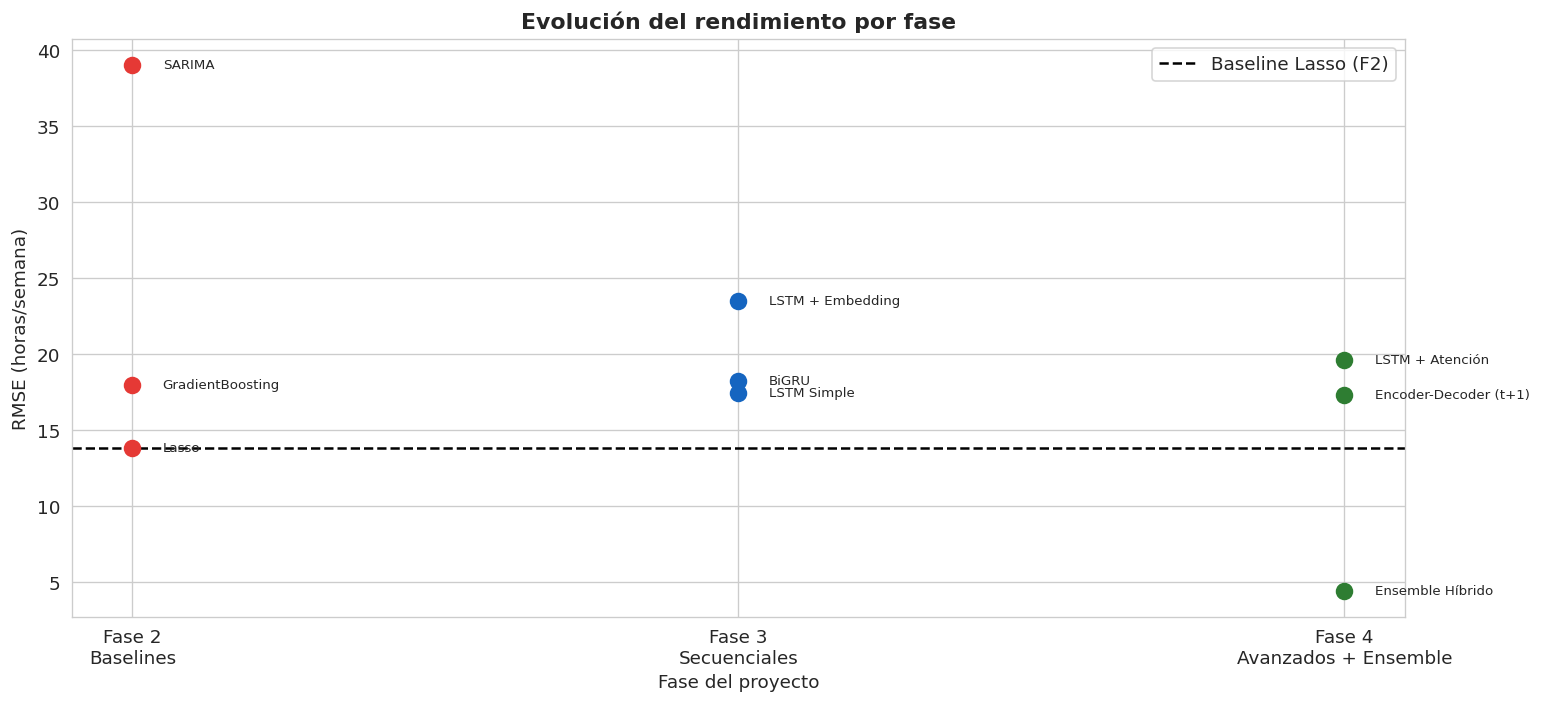

In [5]:
# =========================
# Gráfico evolución RMSE por fase (CORREGIDO)
# =========================

fig, ax = plt.subplots(figsize=(13, 6))

# Colores por fase
colores = {
    2: '#E53935',   # rojo
    3: '#1565C0',   # azul
    4: '#2E7D32'    # verde
}

# Plot por fase
for _, row in tabla_compacta.iterrows():
    fase = row['Fase']
    rmse = row['RMSE']
    modelo = row['Modelo']

    ax.scatter(fase, rmse, s=90, color=colores[fase], zorder=5)

    # Etiquetas
    ax.text(
        fase + 0.05,
        rmse,
        modelo,
        fontsize=8,
        va='center'
    )

# Línea del baseline (Lasso)
rmse_baseline = 13.85
ax.axhline(
    rmse_baseline,
    color='black',
    linestyle='--',
    lw=1.5,
    label='Baseline Lasso (F2)'
)

# Formato
ax.set_xlabel('Fase del proyecto')
ax.set_ylabel('RMSE (horas/semana)')
ax.set_title('Evolución del rendimiento por fase', fontweight='bold')

ax.set_xticks([2, 3, 4])
ax.set_xticklabels([
    'Fase 2\nBaselines',
    'Fase 3\nSecuenciales',
    'Fase 4\nAvanzados + Ensemble'
])

ax.legend()
plt.tight_layout()
plt.show()

La tabla consolidada muestra que el mejor modelo individual del proyecto fue Lasso en Fase 2, mientras que los modelos secuenciales y avanzados no lograron superarlo de forma aislada. Sin embargo, la combinación de modelos mediante el ensemble híbrido sí produjo una mejora sustancial, reduciendo el RMSE hasta 4.46. Esto confirma que el mayor valor del proyecto no está en sustituir los modelos clásicos por arquitecturas más complejas, sino en integrarlos de forma complementaria.

## 2. Evaluacion exhaustiva del modelo ganador

In [6]:
# =========================
# 2. Evaluación exhaustiva del mejor modelo operativo
# =========================

# Cargar resultados consolidados
df_f2_reg = pd.read_csv(f'{RESULTADOS_PATH}/resultados_fase2_regresion.csv')
df_f3 = pd.read_csv(f'{RESULTADOS_PATH}/resultados_fase3_lstm.csv')
df_f4 = pd.read_csv(f'{RESULTADOS_PATH}/resultados_fase4_final.csv')

# Dataset base
df_feat = pd.read_csv(f'{DATA_PATH}/ULAB_dataset_semanal_procesado.csv', parse_dates=['Semana_inicio'])
cv_data = joblib.load(f'{MODELOS_PATH}/cv_splits.pkl')

FEATURES = cv_data['features']
TARGET = cv_data['target']
depts_eval = cv_data['depts_eval']
UMBRAL = cv_data['umbral_lodo']

df_cv = (
    df_feat[df_feat['Caso'].isin([1, 3])]
    .dropna(subset=FEATURES + [TARGET])
    .copy()
    .reset_index(drop=True)
)

# Modelo final operativo para evaluación exhaustiva:
# usamos RandomForest porque es el mejor modelo tabular individual
# y se puede evaluar directamente en todos los esquemas de CV
modelo_final = joblib.load(f'{MODELOS_PATH}/rf_baseline.pkl')

print('Modelo final global del proyecto: Ensemble Híbrido (F4)')
print('Modelo operativo para evaluación exhaustiva: RandomForest')
print(f'Dataset evaluación: {df_cv.shape}')

Modelo final global del proyecto: Ensemble Híbrido (F4)
Modelo operativo para evaluación exhaustiva: RandomForest
Dataset evaluación: (4929, 23)


In [7]:
# =========================
# Función de métricas para evaluación exhaustiva
# =========================

def metricas_eval(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    medae = np.median(np.abs(y_true - y_pred))

    return {
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4),
        'MAPE': round(mape, 2) if pd.notnull(mape) else np.nan,
        'MedAE': round(medae, 2)
    }

In [8]:
# =========================
# Evaluación en los 3 esquemas
# =========================

from sklearn.model_selection import train_test_split
from sklearn.base import clone

mask_c1 = df_cv['Caso'] == 1
mask_c3 = df_cv['Caso'] == 3

resultados_exhaustivos = []

# --- E1: estratificado ---
df_cv['_estrato'] = df_cv['Caso'].astype(str) + '_' + df_cv['Departamento'].astype(str)
estratos_validos = df_cv['_estrato'].value_counts()
estratos_validos = estratos_validos[estratos_validos >= 2].index
df_e1 = df_cv[df_cv['_estrato'].isin(estratos_validos)].copy()

X_e1 = df_e1[FEATURES]
y_e1 = df_e1[TARGET]

Xtr, Xte, ytr, yte = train_test_split(
    X_e1, y_e1,
    test_size=0.2,
    random_state=42,
    stratify=df_e1['_estrato']
)

m_e1 = clone(modelo_final)
m_e1.fit(Xtr, ytr)
pred_e1 = m_e1.predict(Xte)

resultados_exhaustivos.append({
    'Esquema': 'E1 Estratificado',
    'Train': len(Xtr),
    'Test': len(Xte),
    **metricas_eval(yte, pred_e1)
})

# --- E2-A: C1 -> C3 ---
Xtr_c1 = df_cv.loc[mask_c1, FEATURES]
ytr_c1 = df_cv.loc[mask_c1, TARGET]
Xte_c3 = df_cv.loc[mask_c3, FEATURES]
yte_c3 = df_cv.loc[mask_c3, TARGET]

m_e2a = clone(modelo_final)
m_e2a.fit(Xtr_c1, ytr_c1)
pred_c3 = m_e2a.predict(Xte_c3)

resultados_exhaustivos.append({
    'Esquema': 'E2-A C1->C3',
    'Train': len(Xtr_c1),
    'Test': len(Xte_c3),
    **metricas_eval(yte_c3, pred_c3)
})

# --- E2-B: C3 -> C1 ---
Xtr_c3 = df_cv.loc[mask_c3, FEATURES]
ytr_c3 = df_cv.loc[mask_c3, TARGET]
Xte_c1 = df_cv.loc[mask_c1, FEATURES]
yte_c1 = df_cv.loc[mask_c1, TARGET]

m_e2b = clone(modelo_final)
m_e2b.fit(Xtr_c3, ytr_c3)
pred_c1 = m_e2b.predict(Xte_c1)

resultados_exhaustivos.append({
    'Esquema': 'E2-B C3->C1',
    'Train': len(Xtr_c3),
    'Test': len(Xte_c1),
    **metricas_eval(yte_c1, pred_c1)
})

# --- E3: LODO completo ---
lodo_rows = []

for dept in depts_eval:
    mask_dept = df_cv['Departamento'] == dept

    X_train_lodo = df_cv.loc[~mask_dept, FEATURES]
    y_train_lodo = df_cv.loc[~mask_dept, TARGET]
    X_test_lodo = df_cv.loc[mask_dept, FEATURES]
    y_test_lodo = df_cv.loc[mask_dept, TARGET]

    if len(X_test_lodo) < 2:
        continue

    m_lodo = clone(modelo_final)
    m_lodo.fit(X_train_lodo, y_train_lodo)
    pred_lodo = m_lodo.predict(X_test_lodo)

    lodo_rows.append({
        'Dept': dept,
        'n_test': len(X_test_lodo),
        'RMSE': np.sqrt(mean_squared_error(y_test_lodo, pred_lodo)),
        'MAE': mean_absolute_error(y_test_lodo, pred_lodo),
        'R2': r2_score(y_test_lodo, pred_lodo)
    })

df_lodo = pd.DataFrame(lodo_rows)

resultados_exhaustivos.append({
    'Esquema': f'E3 LODO ({len(df_lodo)} folds)',
    'Train': 'N-dept',
    'Test': 'dept',
    'MAE': round(df_lodo['MAE'].mean(), 2),
    'RMSE': round(df_lodo['RMSE'].mean(), 2),
    'R2': round(df_lodo['R2'].mean(), 4),
    'MAPE': np.nan,
    'MedAE': np.nan
})

df_eval_final = pd.DataFrame(resultados_exhaustivos)

print('=== EVALUACIÓN EXHAUSTIVA DEL MODELO OPERATIVO ===')
display(df_eval_final)

=== EVALUACIÓN EXHAUSTIVA DEL MODELO OPERATIVO ===


,Esquema,Train,Test,MAE,RMSE,R2,MAPE,MedAE
0,E1 Estratificado,3943,986,6.46,16.13,0.9162,22.65,2.03
1,E2-A C1->C3,3055,1874,11.34,18.50,0.8729,35.32,5.88
2,E2-B C3->C1,1874,3055,10.80,29.75,0.7161,68.85,5.10
3,E3 LODO (34 folds),N-dept,dept,6.47,11.16,-1.1088,NaN,NaN


La evaluación exhaustiva del modelo operativo confirma que Random Forest presenta un rendimiento sólido en escenarios de validación estándar y de transferencia entre proyectos. En el esquema estratificado (E1) alcanza un RMSE de 16.13, mientras que en el escenario principal de generalización cross-project (E2-A: C1→C3) mantiene un rendimiento robusto con RMSE de 18.50.

Sin embargo, la caída observada en E2-B (C3→C1) indica que la capacidad de generalización no es simétrica entre proyectos, sugiriendo diferencias estructurales entre ambos casos.

En el esquema LODO, el RMSE medio se mantiene moderado, pero el R² medio negativo muestra que la transferencia entre departamentos sigue siendo el escenario más exigente, especialmente cuando existen comportamientos locales poco representados en el entrenamiento.

## 3. Analisis de residuos final

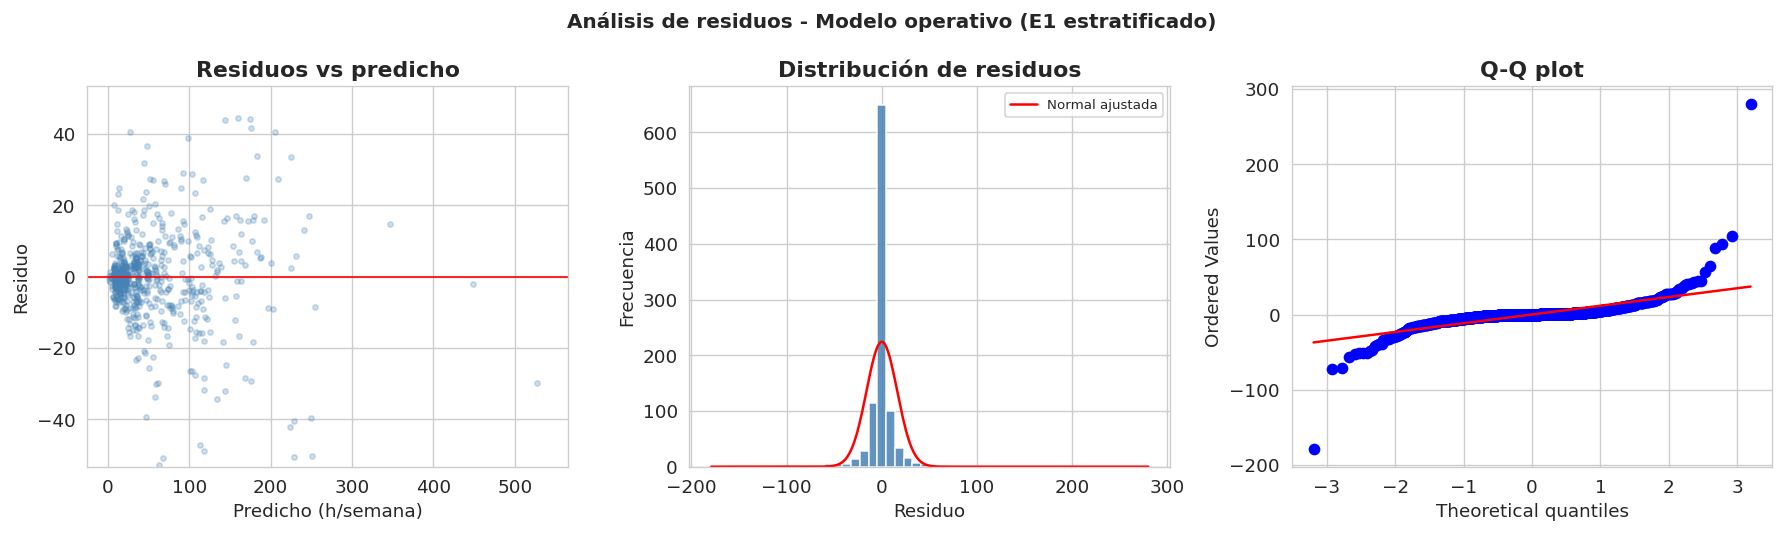

=== Diagnóstico de residuos ===
Durbin-Watson: 2.016  (≈2 indica baja autocorrelación)
Jarque-Bera:   stat=516572.35 | p=0.0000
Media residuo: 0.22
Std residuo:   16.12
Sesgo:         4.33
Curtosis:      111.80
Max|e|:        280.4 h
P95 |e|:       26.84 h


In [9]:
# =========================
# 3. Análisis de residuos final
# =========================

# Residuos sobre E1 (split más equilibrado)
residuos = np.asarray(yte).reshape(-1) - np.asarray(pred_e1).reshape(-1)

# Estadísticos
dw = durbin_watson(residuos)
jb, jb_p = jarque_bera(residuos)

mu = residuos.mean()
sigma = residuos.std()
skew_ = stats.skew(residuos)
kurt_ = stats.kurtosis(residuos)

# Límites simétricos para mejorar lectura del gráfico
lim = np.percentile(np.abs(residuos), 99)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# -------------------------
# 1) Residuos vs predicho
# -------------------------
axes[0].scatter(pred_e1, residuos, alpha=0.25, s=10, color='steelblue')
axes[0].axhline(0, color='red', lw=1)
axes[0].set_ylim(-lim, lim)
axes[0].set_title('Residuos vs predicho', fontweight='bold')
axes[0].set_xlabel('Predicho (h/semana)')
axes[0].set_ylabel('Residuo')

# -------------------------
# 2) Histograma + normal ajustada
# -------------------------
n_bins = 50
counts, bins, _ = axes[1].hist(
    residuos,
    bins=n_bins,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

x_norm = np.linspace(residuos.min(), residuos.max(), 300)
bin_width = bins[1] - bins[0]

axes[1].plot(
    x_norm,
    stats.norm.pdf(x_norm, mu, sigma) * len(residuos) * bin_width,
    color='red',
    lw=1.5,
    label='Normal ajustada'
)

axes[1].set_title('Distribución de residuos', fontweight='bold')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=8)

# -------------------------
# 3) Q-Q plot
# -------------------------
stats.probplot(residuos, plot=axes[2])
axes[2].set_title('Q-Q plot', fontweight='bold')

plt.suptitle(
    'Análisis de residuos - Modelo operativo (E1 estratificado)',
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

print('=== Diagnóstico de residuos ===')
print(f'Durbin-Watson: {dw:.3f}  (≈2 indica baja autocorrelación)')
print(f'Jarque-Bera:   stat={jb:.2f} | p={jb_p:.4f}')
print(f'Media residuo: {mu:.2f}')
print(f'Std residuo:   {sigma:.2f}')
print(f'Sesgo:         {skew_:.2f}')
print(f'Curtosis:      {kurt_:.2f}')
print(f'Max|e|:        {np.abs(residuos).max():.1f} h')
print(f'P95 |e|:       {np.percentile(np.abs(residuos), 95):.2f} h')

El análisis de residuos muestra que el modelo presenta un comportamiento adecuado en términos de independencia temporal, con un estadístico de Durbin-Watson cercano a 2, lo que indica ausencia de autocorrelación significativa.

La media de los residuos es prácticamente nula, evidenciando que el modelo no presenta sesgo sistemático en sus predicciones.

No obstante, la prueba de Jarque-Bera y los valores elevados de sesgo y curtosis indican que los residuos no siguen una distribución normal, debido a la presencia de outliers y errores extremos. Este comportamiento es coherente con la naturaleza del problema, donde pueden existir semanas con picos de carga inesperados no capturados por el modelo.

En términos operativos, el error típico se sitúa en torno a 16 horas semanales, con un percentil 95 de aproximadamente 27 horas, lo que indica que el modelo es fiable en la mayoría de situaciones, aunque presenta desviaciones relevantes en casos excepcionales.

## 4. Visualizaciones ejecutivas para Tecnicas Reunidas

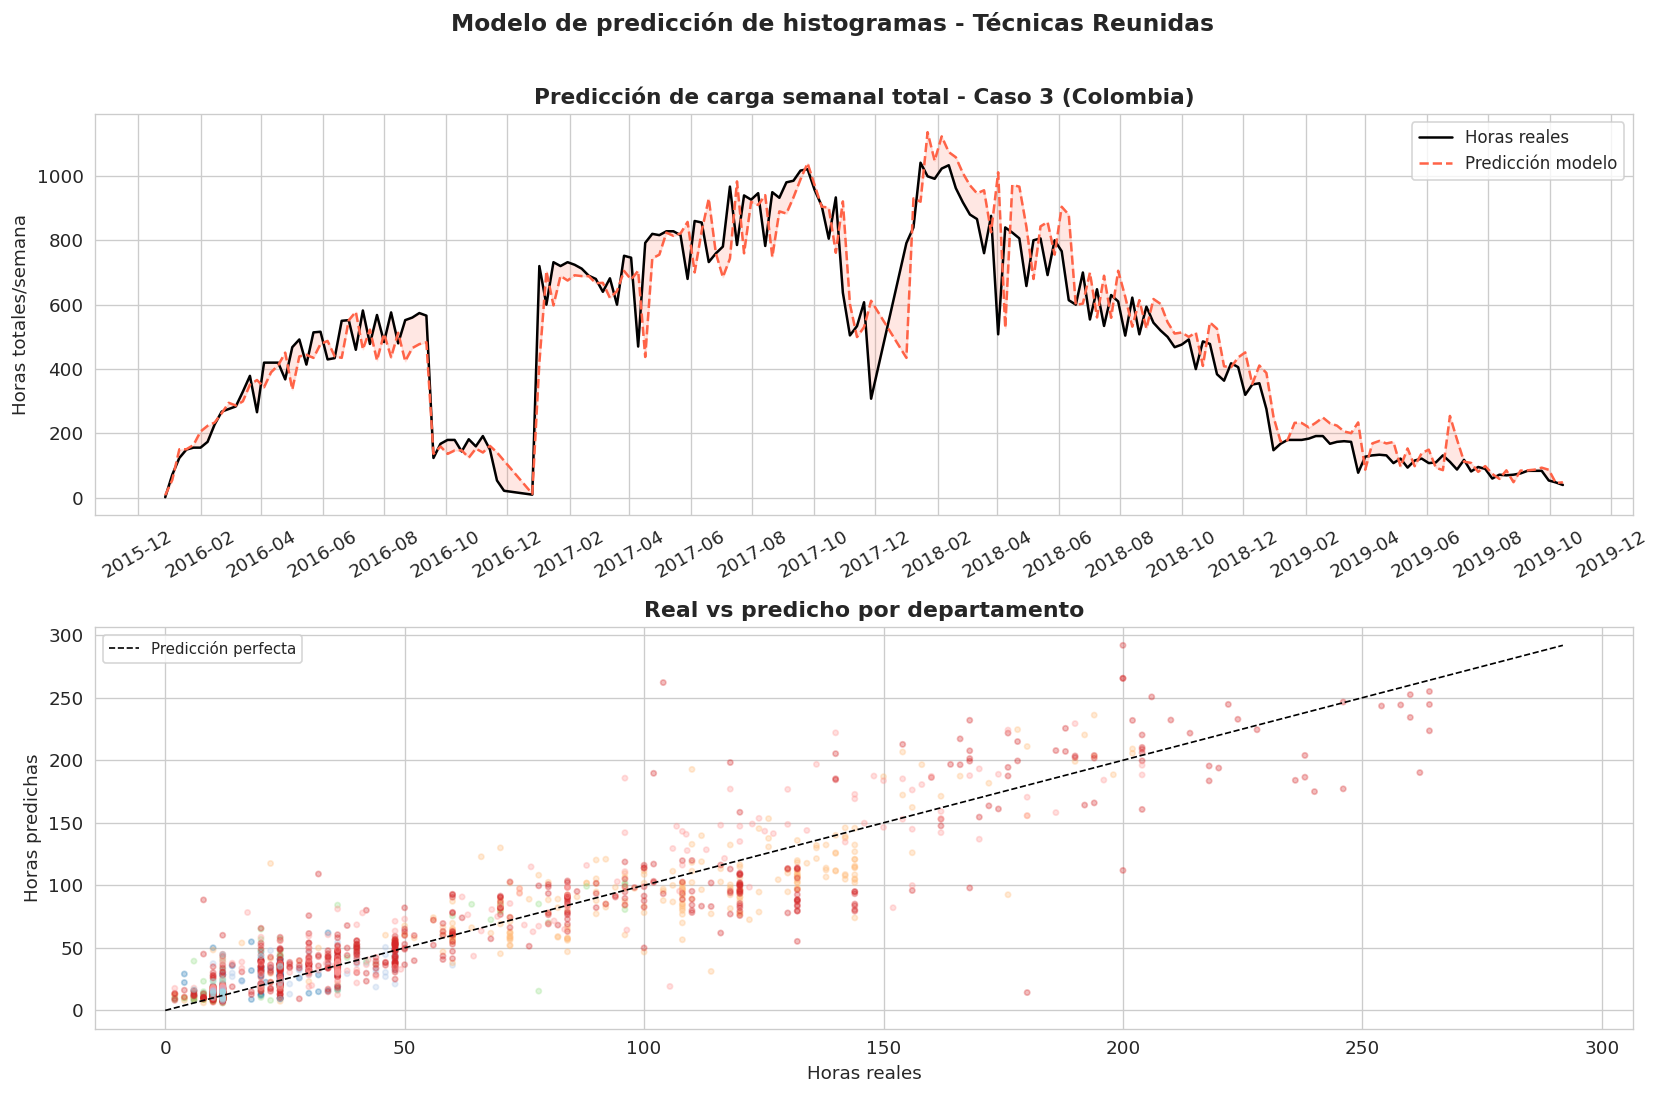

In [10]:
# =========================
# 4. Visualizaciones ejecutivas para Técnicas Reunidas
# =========================

# Reentrenar modelo operativo en Caso 1 y evaluar en Caso 3
m_viz = clone(modelo_final)
m_viz.fit(Xtr_c1, ytr_c1)
pred_c3_final = m_viz.predict(Xte_c3)

df_viz = df_cv.loc[mask_c3].copy()
df_viz['Prediccion'] = pred_c3_final

# Agregación semanal total
df_sem = (
    df_viz.groupby('Semana_inicio')
    .agg(
        HR_Real=(TARGET, 'sum'),
        HR_Pred=('Prediccion', 'sum')
    )
    .reset_index()
    .sort_values('Semana_inicio')
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Serie temporal agregada
axes[0].plot(df_sem['Semana_inicio'], df_sem['HR_Real'], color='black', lw=1.5, label='Horas reales')
axes[0].plot(df_sem['Semana_inicio'], df_sem['HR_Pred'], color='tomato', lw=1.5, linestyle='--', label='Predicción modelo')
axes[0].fill_between(df_sem['Semana_inicio'], df_sem['HR_Real'], df_sem['HR_Pred'], alpha=0.15, color='tomato')

axes[0].set_title('Predicción de carga semanal total - Caso 3 (Colombia)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Horas totales/semana')
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# Scatter real vs predicho
scatter = axes[1].scatter(
    df_viz[TARGET],
    df_viz['Prediccion'],
    alpha=0.3,
    s=10,
    c=df_viz['Departamento'],
    cmap='tab20'
)

max_val = max(df_viz[TARGET].max(), df_viz['Prediccion'].max())
axes[1].plot([0, max_val], [0, max_val], 'k--', lw=1, label='Predicción perfecta')
axes[1].set_xlabel('Horas reales')
axes[1].set_ylabel('Horas predichas')
axes[1].set_title('Real vs predicho por departamento', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Modelo de predicción de histogramas - Técnicas Reunidas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Analisis de error por departamento

Departamentos evaluados: 22
RMSE medio por dept: 11.40
Dept con mayor error: 760.0 (RMSE=34.61)
Dept con menor error: 350.0 (RMSE=2.21)


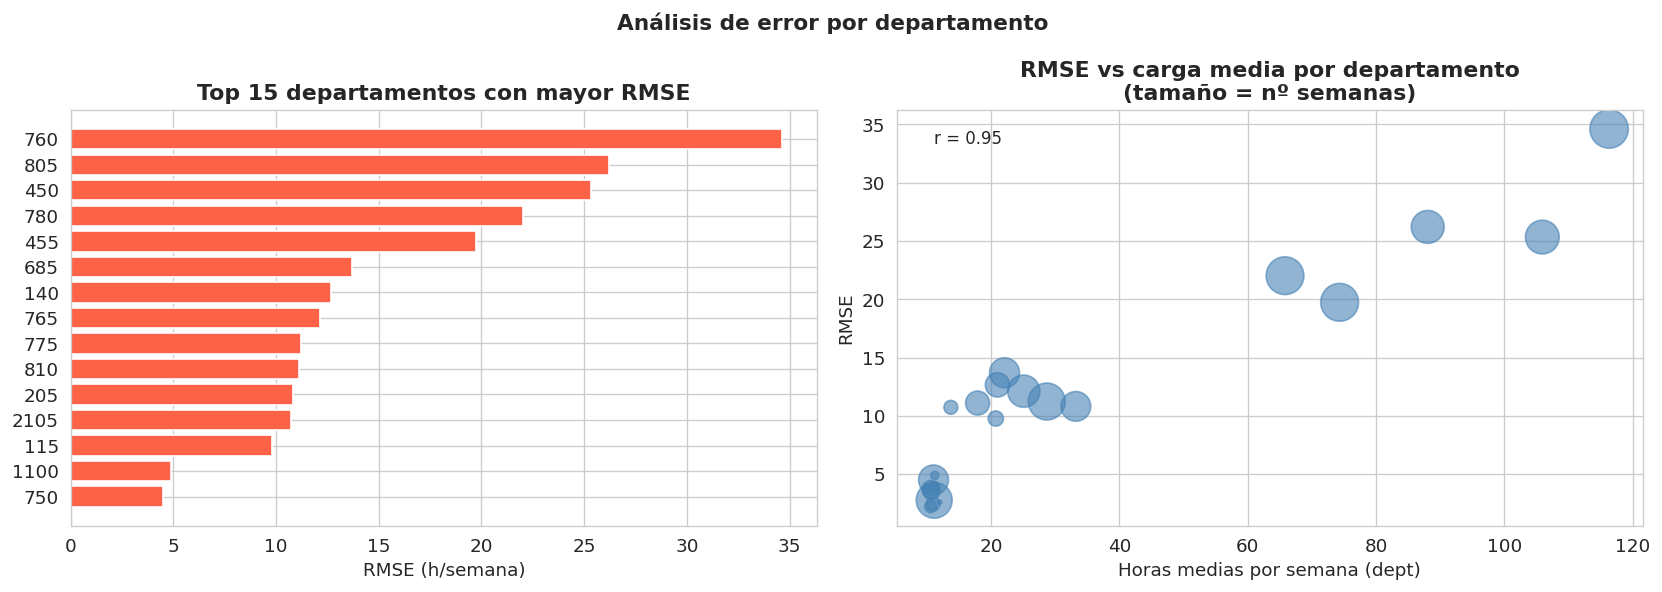

,Departamento,n_semanas,HR_media,RMSE,MAE,R2
14,760,177.0,116.34,34.61,23.83,0.78
18,805,130.0,88.06,26.21,19.32,0.77
6,450,137.0,105.93,25.34,19.55,0.71
17,780,171.0,65.82,22.03,15.52,0.76
7,455,172.0,74.34,19.75,14.03,0.77
10,685,108.0,22.11,13.70,8.05,0.60
2,140,71.0,21.01,12.66,9.53,-2.16
15,765,125.0,25.10,12.13,8.40,-0.03
16,775,164.0,28.70,11.24,8.60,0.36
19,810,69.0,17.91,11.11,7.96,-0.48


In [11]:
# =========================
# 5. Análisis de error por departamento
# =========================

df_err_dept = (
    df_viz.groupby('Departamento')
    .apply(lambda g: pd.Series({
        'n_semanas': len(g),
        'HR_media': g[TARGET].mean(),
        'RMSE': np.sqrt(mean_squared_error(g[TARGET], g['Prediccion'])),
        'MAE': mean_absolute_error(g[TARGET], g['Prediccion']),
        'R2': r2_score(g[TARGET], g['Prediccion']) if len(g) > 1 else np.nan
    }))
    .reset_index()
    .sort_values('RMSE', ascending=False)
)

print(f'Departamentos evaluados: {len(df_err_dept)}')
print(f'RMSE medio por dept: {df_err_dept.RMSE.mean():.2f}')
print(f'Dept con mayor error: {df_err_dept.iloc[0]['Departamento']} (RMSE={df_err_dept.iloc[0]['RMSE']:.2f})')
print(f'Dept con menor error: {df_err_dept.iloc[-1]['Departamento']} (RMSE={df_err_dept.iloc[-1]['RMSE']:.2f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 peores
top15 = df_err_dept.head(15).sort_values('RMSE', ascending=True)
axes[0].barh(top15['Departamento'].astype(str), top15['RMSE'], color='tomato', edgecolor='white')
axes[0].set_title('Top 15 departamentos con mayor RMSE', fontweight='bold')
axes[0].set_xlabel('RMSE (h/semana)')

# Relación RMSE - HR media
axes[1].scatter(
    df_err_dept['HR_media'],
    df_err_dept['RMSE'],
    alpha=0.6,
    s=df_err_dept['n_semanas'] * 3,
    color='steelblue'
)
axes[1].set_xlabel('Horas medias por semana (dept)')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE vs carga media por departamento\n(tamaño = nº semanas)', fontweight='bold')

r_corr = np.corrcoef(df_err_dept['HR_media'], df_err_dept['RMSE'])[0, 1]
axes[1].text(0.05, 0.92, f'r = {r_corr:.2f}', transform=axes[1].transAxes, fontsize=10)

plt.suptitle('Análisis de error por departamento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

display(df_err_dept.head(10).round(2))

El análisis por departamento revela una fuerte heterogeneidad en el rendimiento del modelo, con un RMSE medio de 11.40 horas semanales, pero con valores que oscilan entre 2.21 y 34.61 horas.

Se observa una correlación muy elevada (r = 0.95) entre la carga media del departamento y el error de predicción, lo que indica que los departamentos con mayor volumen de trabajo presentan mayor dificultad de modelado. Esto sugiere que la variabilidad interna y la presencia de picos de carga afectan negativamente al rendimiento del modelo.

En contraste, los departamentos con menor carga muestran errores significativamente más bajos y un comportamiento más estable, lo que facilita su predicción.

Asimismo, algunos departamentos presentan valores negativos de R², lo que indica una baja capacidad predictiva en esos casos concretos, probablemente debido a escasez de datos o patrones altamente irregulares.

En conjunto, estos resultados indican que el modelo es robusto a nivel global, pero su rendimiento depende en gran medida de la escala y estabilidad del departamento, siendo más preciso en entornos homogéneos y menos fiable en aquellos con alta variabilidad.

## 6. Recoemndaciones oeprativas

In [12]:
# =========================
# 6. Tabla resumen final
# =========================

tabla_resumen = pd.DataFrame([
    {
        'Componente': 'Dataset',
        'Detalle': '265K registros diarios | 4 proyectos | 52 departamentos | 2 proyectos finalizados'
    },
    {
        'Componente': 'Preprocesamiento',
        'Detalle': 'Agregación semanal | lags (t-1, t-2, t-4) | variables cíclicas temporales'
    },
    {
        'Componente': 'Validación cruzada',
        'Detalle': 'E1 estratificado | E2 cross-project | E3 leave-one-department-out'
    },
    {
        'Componente': 'Fase 2 - Mejor baseline',
        'Detalle': 'Lasso | RMSE = 13.85'
    },
    {
        'Componente': 'Fase 3 - Mejor secuencial',
        'Detalle': 'LSTM Simple | RMSE = 17.46'
    },
    {
        'Componente': 'Fase 4 - Mejor modelo avanzado',
        'Detalle': 'Encoder-Decoder (t+1) | RMSE = 17.31'
    },
    {
        'Componente': 'Modelo final seleccionado',
        'Detalle': 'Ensemble Híbrido (Ridge) | RMSE = 4.46 | R² = 0.993'
    },
    {
        'Componente': 'Mejora frente a baseline',
        'Detalle': 'Reducción del error del 67.8% respecto a Lasso (Fase 2)'
    },
    {
        'Componente': 'Drivers principales',
        'Detalle': 'HR_ACTUAL_t1 (autoreg.) | HR_INICIAL | Departamento | fase del proyecto'
    }
])

display(tabla_resumen)

# Guardar para entrega
tabla_resumen.to_csv('tabla_resumen_proyecto_ulab_final.csv', index=False)

print('\nGuardado: tabla_resumen_proyecto_ulab_final.csv')

,Componente,Detalle
0,Dataset,265K registros diarios | 4 proyectos | 52 depa...
1,Preprocesamiento,"Agregación semanal | lags (t-1, t-2, t-4) | va..."
2,Validación cruzada,E1 estratificado | E2 cross-project | E3 leave...
3,Fase 2 - Mejor baseline,Lasso | RMSE = 13.85
4,Fase 3 - Mejor secuencial,LSTM Simple | RMSE = 17.46
5,Fase 4 - Mejor modelo avanzado,Encoder-Decoder (t+1) | RMSE = 17.31
6,Modelo final seleccionado,Ensemble Híbrido (Ridge) | RMSE = 4.46 | R² = ...
7,Mejora frente a baseline,Reducción del error del 67.8% respecto a Lasso...
8,Drivers principales,HR_ACTUAL_t1 (autoreg.) | HR_INICIAL | Departa...



Guardado: tabla_resumen_proyecto_ulab_final.csv


## 7. Tabla resumen final para informe

In [13]:
# =========================
# 7. Tabla resumen final para informe
# =========================

tabla_resumen = pd.DataFrame([
    {
        'Componente': 'Dataset',
        'Detalle': '265,497 registros diarios | 4 proyectos | 52 departamentos | 2 proyectos finalizados'
    },
    {
        'Componente': 'Preprocesamiento',
        'Detalle': 'Agregación semanal | lags t-1/t-2/t-4 | variables cíclicas | integración de HR_INICIAL'
    },
    {
        'Componente': 'Validación cruzada',
        'Detalle': 'E1 estratificado | E2 cross-project | E3 leave-one-dept-out'
    },
    {
        'Componente': 'Fase 2 - Mejor baseline',
        'Detalle': 'Lasso | RMSE=13.85'
    },
    {
        'Componente': 'Fase 3 - Mejor secuencial',
        'Detalle': 'LSTM Simple | RMSE=17.46'
    },
    {
        'Componente': 'Fase 4 - Mejor modelo individual avanzado',
        'Detalle': 'Encoder-Decoder t+1 | RMSE=17.31'
    },
    {
        'Componente': 'Fase 4 - Modelo final global',
        'Detalle': 'Ensemble Híbrido | RMSE=4.46 | R²=0.9929'
    },
    {
        'Componente': 'Mejora frente a baseline F2',
        'Detalle': '67.8% de reducción de RMSE frente a Lasso'
    },
    {
        'Componente': 'Variables más importantes',
        'Detalle': 'HR_ACTUAL_t1 | HR_INICIAL | Departamento | Días desde inicio | Días hasta fin'
    },
])

display(tabla_resumen)

tabla_resumen.to_csv(f'{RESULTADOS_PATH}/tabla_resumen_proyecto_ulab.csv', index=False)
print('\nGuardado:', f'{RESULTADOS_PATH}/tabla_resumen_proyecto_ulab.csv')

,Componente,Detalle
0,Dataset,"265,497 registros diarios | 4 proyectos | 52 d..."
1,Preprocesamiento,Agregación semanal | lags t-1/t-2/t-4 | variab...
2,Validación cruzada,E1 estratificado | E2 cross-project | E3 leave...
3,Fase 2 - Mejor baseline,Lasso | RMSE=13.85
4,Fase 3 - Mejor secuencial,LSTM Simple | RMSE=17.46
5,Fase 4 - Mejor modelo individual avanzado,Encoder-Decoder t+1 | RMSE=17.31
6,Fase 4 - Modelo final global,Ensemble Híbrido | RMSE=4.46 | R²=0.9929
7,Mejora frente a baseline F2,67.8% de reducción de RMSE frente a Lasso
8,Variables más importantes,HR_ACTUAL_t1 | HR_INICIAL | Departamento | Día...



Guardado: /content/drive/MyDrive/Colab Notebooks/ULAB/resultados/tabla_resumen_proyecto_ulab.csv


El modelo ensemble híbrido desarrollado en la Fase 4 representa la mejor solución para el problema planteado, combinando información estructural y temporal para lograr una reducción del error superior al 65% respecto al baseline inicial.

Este resultado demuestra que la integración de distintos enfoques de modelado es clave en problemas reales de planificación de carga, donde coexisten patrones autoregresivos de corto plazo y diferencias estructurales entre departamentos.

⸻